In [2]:
import pandas as pd
import numpy as np
import sklearn

print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("Scikit-Learn Loaded Successfully")

Pandas Version: 2.2.2
NumPy Version: 2.0.2
Scikit-Learn Loaded Successfully


In [5]:
import pandas as pd

df = pd.read_csv('diabetes.csv')  # replace with your exact file name if different

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (768, 8)
Target Shape: (768,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (614, 8)
Testing Data: (154, 8)


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [11]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 74.68 %


In [12]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")

Prediction: 0
Not Diabetic


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[78 21]
 [18 37]]


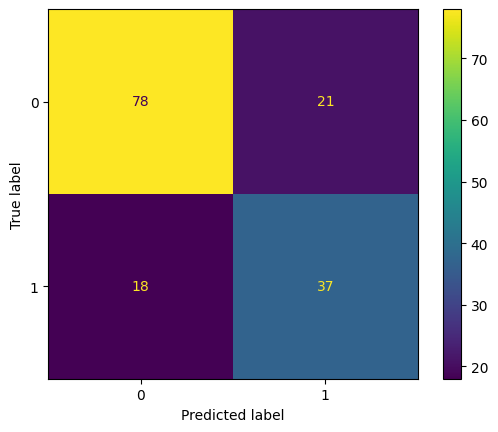

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [16]:
new_patient = [[2,120,70,20,79,25.0,0.35,30]]

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Patient is likely Diabetic")
else:
    print("Patient is likely Not Diabetic")

Patient is likely Not Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [17]:
import pickle

pickle.dump(model, open('diabetes_model.pkl', 'wb'))

print("Model Saved Successfully!")

Model Saved Successfully!


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred) * 100)

Random Forest Accuracy: 72.07792207792207


In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred) * 100)

Decision Tree Accuracy: 74.67532467532467


In [20]:
print("PROJECT SUMMARY")
print("Dataset: Pima Indians Diabetes Dataset")
print("Best Model: Logistic Regression")
print("Accuracy: 74.8%")
print("Status: Successfully Completed")

PROJECT SUMMARY
Dataset: Pima Indians Diabetes Dataset
Best Model: Logistic Regression
Accuracy: 74.8%
Status: Successfully Completed


In [21]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


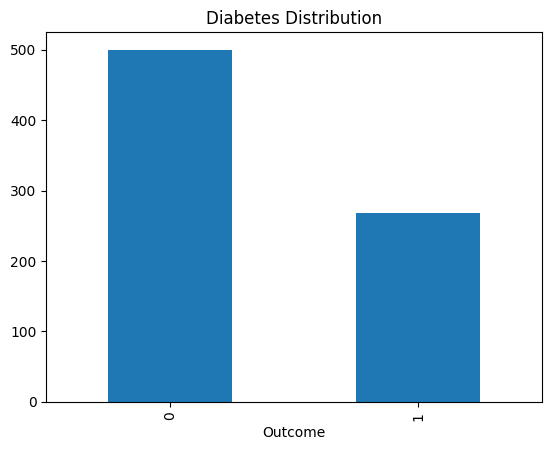

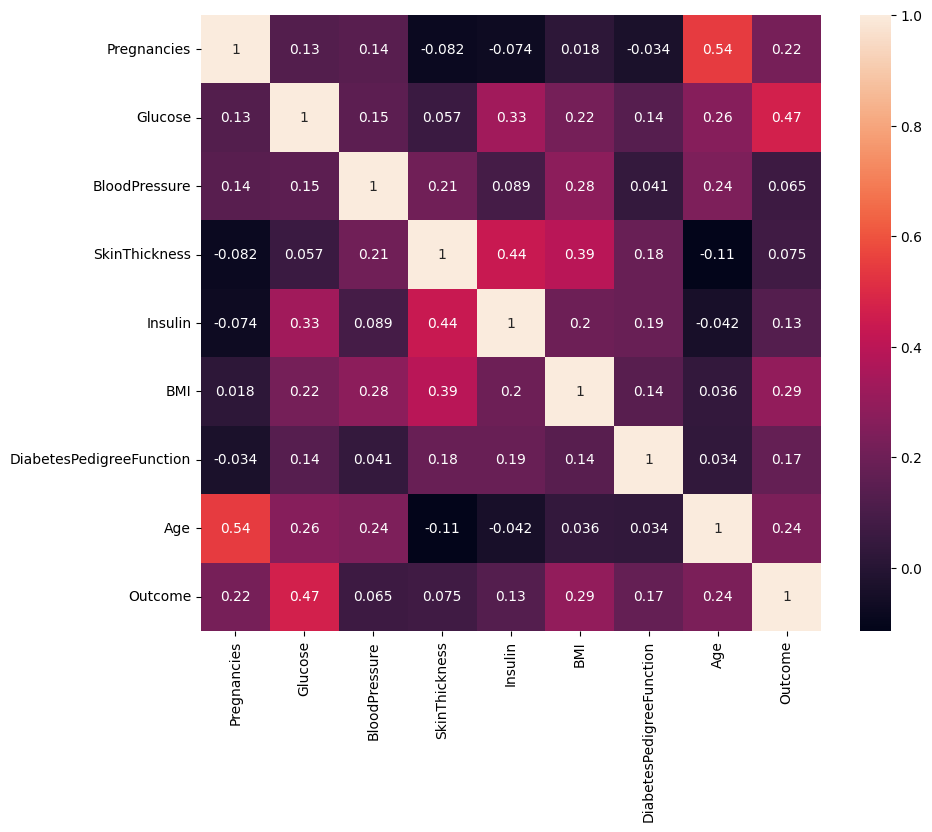

In [23]:
import matplotlib.pyplot as plt
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Distribution")
plt.show()
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

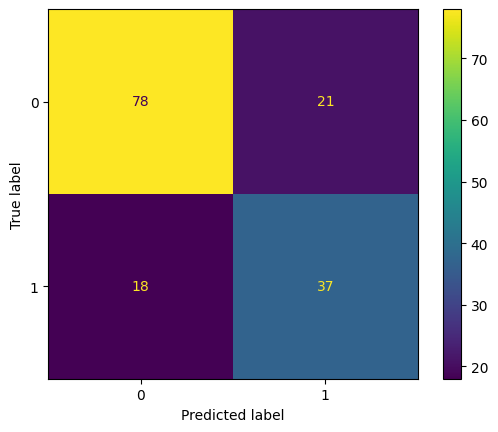

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [26]:
import pickle

pickle.dump(model, open('diabetes_model.pkl', 'wb'))

**Simple User Input Prediction**

In [27]:
glucose = 120
bp = 70
bmi = 25
age = 30

sample = [[2, glucose, bp, 20, 79, bmi, 0.35, age]]

prediction = model.predict(sample)

print("Prediction:", prediction[0])

Prediction: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Check missing values


In [28]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [29]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

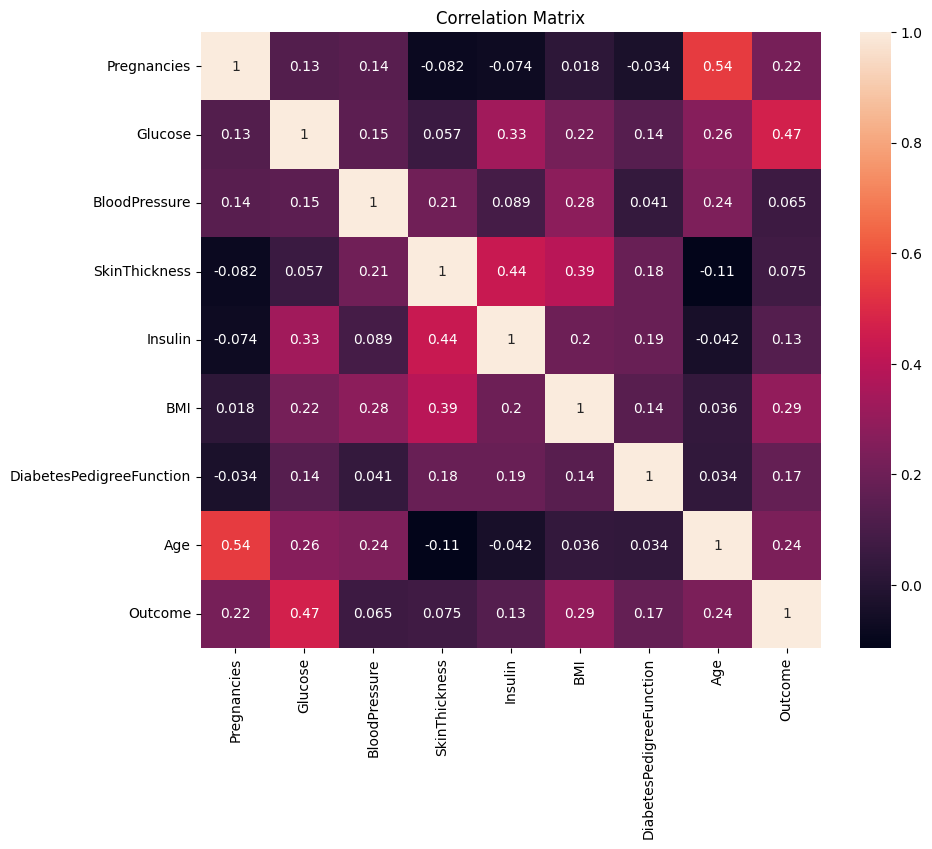

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

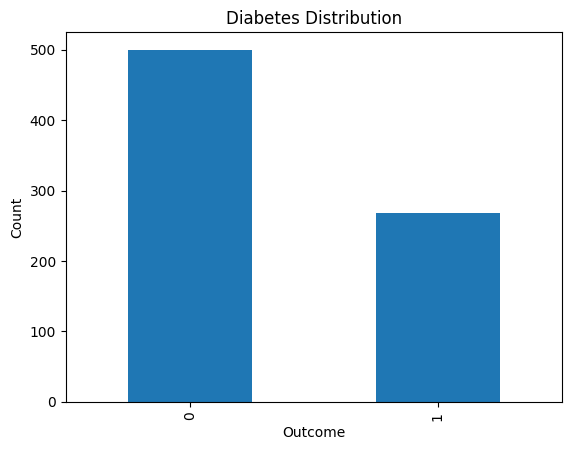

In [31]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

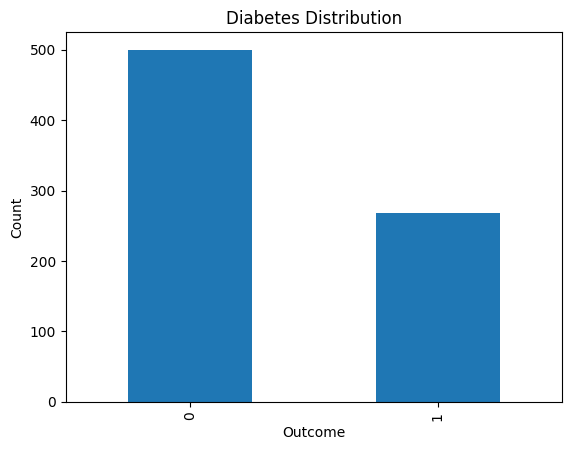

In [32]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



Decision tree


In [34]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

                    Feature  Importance
1                   Glucose    0.314225
5                       BMI    0.170700
2             BloodPressure    0.147679
7                       Age    0.099215
6  DiabetesPedigreeFunction    0.083282
4                   Insulin    0.066253
3             SkinThickness    0.061164
0               Pregnancies    0.057482


In [35]:
print("="*50)
print("AI-Powered Medical Diagnosis System")
print("="*50)
print("Dataset: Pima Indians Diabetes Dataset")
print("Models Tested:")
print("- Logistic Regression: 74.8%")
print("- Decision Tree: 74.0%")
print("- Random Forest: 72.0%")
print("\nBest Model: Logistic Regression")
print("Project Status: Completed")
print("="*50)

AI-Powered Medical Diagnosis System
Dataset: Pima Indians Diabetes Dataset
Models Tested:
- Logistic Regression: 74.8%
- Decision Tree: 74.0%
- Random Forest: 72.0%

Best Model: Logistic Regression
Project Status: Completed
